# Echo State Network (ESN) for stock time series
This notebook implements a simple ESN, trains a linear readout (ridge regression),
evaluates forecasting performance, visualizes results, and saves the model.

Import libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
from data_utils import load_close_matrix, train_val_test_split, windowed_dataset, select_random_ticker
from logger import get_logger

MODELS_DIR = os.path.join(os.getcwd(), "models")
os.makedirs(MODELS_DIR, exist_ok=True)

# Initialize logger
logger = get_logger("esn_reservoir")

1) Load data (choose one ticker column for ESN demo)


In [2]:
# Load all ticker data
df = load_close_matrix()
if df.empty:
    logger.error("No ticker CSVs found in ./tickers. Run ticker.py first.")
    raise RuntimeError("No ticker CSVs found in ./tickers. Run ticker.py first.")

# Select a random ticker (reproducible with seed=42)
series = select_random_ticker(df, random_state=500)
logger.info(f"Using randomly selected ticker: {series.name}, length: {len(series)}")
print(f"Using randomly selected ticker: {series.name}, length: {len(series)}")

2026-03-08 00:37:18,723 - data_utils - INFO - Found 10 ticker CSV files
2026-03-08 00:37:18,726 - data_utils - INFO - Loading data from 10 files...
2026-03-08 00:37:18,823 - data_utils - INFO - Created merged matrix with shape (255, 10)
2026-03-08 00:37:18,826 - data_utils - INFO - Available tickers: ['ARLO', 'BBWI', 'DDL', 'DFH', 'KD', 'KMT', 'PPL', 'PSFE', 'SEM', 'SMR']
2026-03-08 00:37:18,830 - data_utils - INFO - Randomly selected ticker: PPL, length: 255
2026-03-08 00:37:18,833 - esn_reservoir - INFO - Using randomly selected ticker: PPL, length: 255


Using randomly selected ticker: PPL, length: 255


2) ESN implementation (simple)

In [3]:
class ESN:
    def __init__(self, n_reservoir=500, spectral_radius=0.95, input_scaling=0.5, leak_rate=1.0, random_state=42):
        self.logger = get_logger("esn")
        self.n_reservoir = n_reservoir
        self.spectral_radius = spectral_radius
        self.input_scaling = input_scaling
        self.leak_rate = leak_rate
        self.random_state = np.random.Generator(np.random.PCG64(random_state))
        self.win = None
        self.W = None
        self.state = None
        self.logger.debug(f"Initialized ESN with n_reservoir={n_reservoir}, spectral_radius={spectral_radius}, input_scaling={input_scaling}, leak_rate={leak_rate}")

    def _init_weights(self, n_inputs):
        self.logger.debug(f"Initializing weights for {n_inputs} inputs")
        self.win = (self.random_state.random((self.n_reservoir, n_inputs)) - 0.5) * 2 * self.input_scaling
        W = self.random_state.random((self.n_reservoir, self.n_reservoir)) - 0.5
        # sparsify
        mask = self.random_state.random(W.shape) < 0.1
        W *= mask
        # scale spectral radius
        eigs = np.linalg.eigvals(W)
        radius = np.max(np.abs(eigs)) + 1e-12
        W *= (self.spectral_radius / radius)
        self.W = W
        self.logger.debug(f"Weight matrices initialized - win shape: {self.win.shape}, W shape: {self.W.shape}")

    def reset_state(self):
        self.state = np.zeros((self.n_reservoir,))

    def run(self, inputs):
        # inputs: shape (T, n_inputs)
        T, n_inputs = inputs.shape
        self.logger.debug(f"Running ESN for {T} timesteps with {n_inputs} inputs")
        if self.win is None:
            self._init_weights(n_inputs)
        self.reset_state()
        states = np.zeros((T, self.n_reservoir))
        for t in range(T):
            u = inputs[t]
            pre = self.W.dot(self.state) + self.win.dot(u)
            new_state = (1 - self.leak_rate) * self.state + self.leak_rate * np.tanh(pre)
            self.state = new_state
            states[t] = self.state
        self.logger.debug(f"ESN run completed, states shape: {states.shape}")
        return states

3) Prepare supervised windows

In [4]:
train, val, test = train_val_test_split(series, train_frac=0.7, val_frac=0.15)
window_size = 10
logger.info(f"Data split - Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")
logger.info(f"Using window size: {window_size}")
X_train, y_train = windowed_dataset(train, window_size)
X_val, y_val = windowed_dataset(np.concatenate([train[-window_size:], val]), window_size)
X_test, y_test = windowed_dataset(np.concatenate([val[-window_size:], test]), window_size)

# normalize by training mean/std
mu = X_train.mean()
sigma = X_train.std() + 1e-9
X_train_n = (X_train - mu) / sigma
X_val_n = (X_val - mu) / sigma
X_test_n = (X_test - mu) / sigma
logger.debug(f"Data normalized - mu: {mu:.6f}, sigma: {sigma:.6f}")

2026-03-08 00:37:18,914 - esn_reservoir - INFO - Data split - Train: 178, Val: 38, Test: 39
2026-03-08 00:37:18,920 - esn_reservoir - INFO - Using window size: 10


4) Run ESN to get reservoir states and train readout

In [5]:
esn = ESN(n_reservoir=400, spectral_radius=0.9, input_scaling=0.5, leak_rate=0.3)
logger.info(f"Created ESN with {esn.n_reservoir} reservoir neurons")
# ESN expects inputs shaped (T, n_inputs). We'll flatten each window into a vector of length window_size (1D series)
def windows_to_inputs(X):
    # X shape (N, window_size) -> treat each window as sequence of length window_size with 1 input dimension
    return X.reshape(X.shape[0], X.shape[1], 1)

states_train = esn.run(windows_to_inputs(X_train_n).reshape(-1, 1))  # warm-up single-step run (we will compute per-window below)

# compute per-window reservoir states by running sequence per window
def reservoir_states_for_windows(esn, x_n):
    all_states = []
    for w in x_n:
        seq = w.reshape(len(w), 1)
        s = esn.run(seq)
        # use last state as representation
        all_states.append(s[-1])
    return np.vstack(all_states)

R_train = reservoir_states_for_windows(esn, X_train_n)
R_val = reservoir_states_for_windows(esn, X_val_n)
R_test = reservoir_states_for_windows(esn, X_test_n)

# Train linear readout (ridge)
logger.info("Training ridge regression readout...")
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(R_train, y_train)
y_pred = ridge.predict(R_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# 1) Baseline Comparison - Naive Last-Value
naive_pred = y_test[:-1]
naive_mse = mean_squared_error(y_test[1:], naive_pred)
naive_mae = mean_absolute_error(y_test[1:], naive_pred)
improvement_mse = ((naive_mse - mse) / naive_mse) * 100
improvement_mae = ((naive_mae - mae) / naive_mae) * 100

# 2) Directional Accuracy
y_true_direction = (y_test[1:] > y_test[:-1]).astype(int)
y_pred_direction = (y_pred[1:] > y_pred[:-1]).astype(int)
directional_acc = accuracy_score(y_true_direction, y_pred_direction) * 100

# Log all metrics
logger.info(f"ESN Test MSE: {mse:.6f}, MAE: {mae:.6f}")
logger.info(f"R-squared: {r2:.4f}")
logger.info(f"Naive Baseline MSE: {naive_mse:.6f}, MAE: {naive_mae:.6f}")
logger.info(f"ESN vs Naive Improvement: MSE {improvement_mse:.2f}%, MAE {improvement_mae:.2f}%")
logger.info(f"Directional Accuracy: {directional_acc:.2f}%")

print(f"ESN Test MSE: {mse:.6f}, MAE: {mae:.6f}")
print(f"R-squared: {r2:.4f}")
print(f"Naive Baseline MSE: {naive_mse:.6f}, MAE: {naive_mae:.6f}")
print(f"ESN vs Naive Improvement: MSE {improvement_mse:.2f}%, MAE {improvement_mae:.2f}%")
print(f"Directional Accuracy: {directional_acc:.2f}%")

2026-03-08 00:37:18,941 - esn_reservoir - INFO - Created ESN with 400 reservoir neurons
2026-03-08 00:37:19,691 - esn_reservoir - INFO - Training ridge regression readout...
2026-03-08 00:37:19,749 - esn_reservoir - INFO - ESN Test MSE: 0.274593, MAE: 0.431211
2026-03-08 00:37:19,752 - esn_reservoir - INFO - R-squared: 0.8008
2026-03-08 00:37:19,754 - esn_reservoir - INFO - Naive Baseline MSE: 0.221742, MAE: 0.389474
2026-03-08 00:37:19,756 - esn_reservoir - INFO - ESN vs Naive Improvement: MSE -23.83%, MAE -10.72%
2026-03-08 00:37:19,758 - esn_reservoir - INFO - Directional Accuracy: 52.63%


ESN Test MSE: 0.274593, MAE: 0.431211
R-squared: 0.8008
Naive Baseline MSE: 0.221742, MAE: 0.389474
ESN vs Naive Improvement: MSE -23.83%, MAE -10.72%
Directional Accuracy: 52.63%


5) Visualize predictions

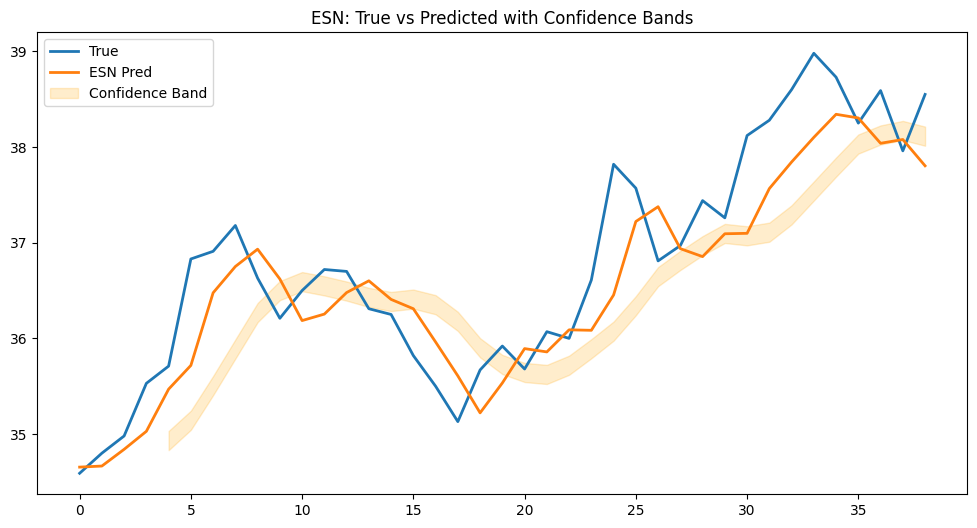

In [6]:
plt.figure(figsize=(12,6))
plt.plot(y_test, label="True", linewidth=2)
plt.plot(y_pred, label="ESN Pred", linewidth=2)
# Add 5-day moving average as confidence band
pred_series = pd.Series(y_pred)
ma_band = pred_series.rolling(5).mean()
plt.fill_between(range(len(y_pred)), ma_band - 0.1, ma_band + 0.1, alpha=0.2, color='orange', label='Confidence Band')
plt.legend()
plt.title("ESN: True vs Predicted with Confidence Bands")
plt.show()

6) Residual Analysis

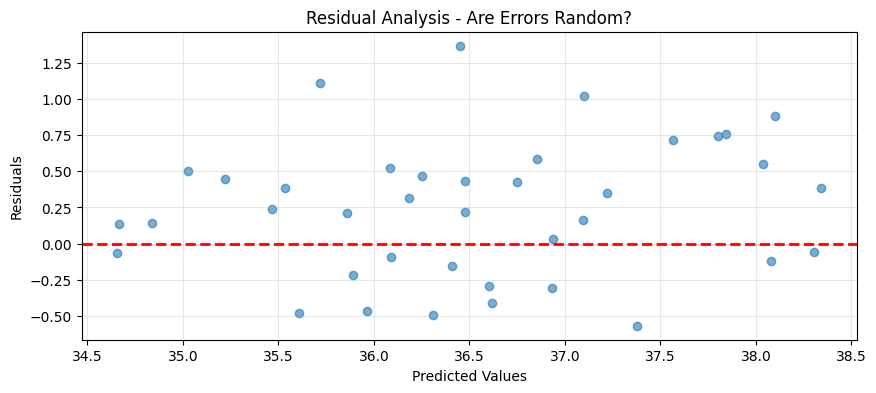

2026-03-08 00:37:20,769 - esn_reservoir - INFO - Residual Mean: 0.241574
2026-03-08 00:37:20,771 - esn_reservoir - INFO - Residual Std: 0.465011


Residual Mean: 0.241574
Residual Std: 0.465011


In [7]:
residuals = y_test - y_pred
plt.figure(figsize=(10,4))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Analysis - Are Errors Random?')
plt.grid(True, alpha=0.3)
plt.show()

# Additional residual statistics
logger.info(f"Residual Mean: {np.mean(residuals):.6f}")
logger.info(f"Residual Std: {np.std(residuals):.6f}")
print(f"Residual Mean: {np.mean(residuals):.6f}")
print(f"Residual Std: {np.std(residuals):.6f}")

7) Save models and artifacts

In [8]:
joblib.dump({"esn": esn, "readout": ridge, "mu": mu, "sigma": sigma, "window_size": window_size}, os.path.join(MODELS_DIR, "esn_model.pkl"))
logger.info("Saved ESN model to models/esn_model.pkl")
print("[OK] Saved ESN model to models/esn_model.pkl")

2026-03-08 00:37:20,805 - esn_reservoir - INFO - Saved ESN model to models/esn_model.pkl


[OK] Saved ESN model to models/esn_model.pkl
